In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.drop_duplicates(inplace=True)

df['director'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df.dropna(inplace=True)

In [4]:
print("Total Content:", len(df))

print("\nContent Types:\n")
print(df['type'].value_counts())

print("\nTop Ratings:\n")
print(df['rating'].value_counts().head())

print("\nTop Countries:\n")
print(df['country'].value_counts().head())

Total Content: 8702

Content Types:

type
Movie      6126
TV Show    2576
Name: count, dtype: int64

Top Ratings:

rating
TV-MA    3183
TV-14    2133
TV-PG     838
R         799
PG-13     490
Name: count, dtype: int64

Top Countries:

country
United States     2775
India              971
Unknown            826
United Kingdom     403
Japan              240
Name: count, dtype: int64


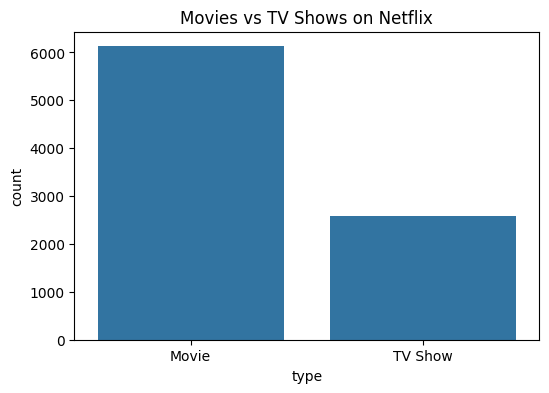

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")

plt.show()

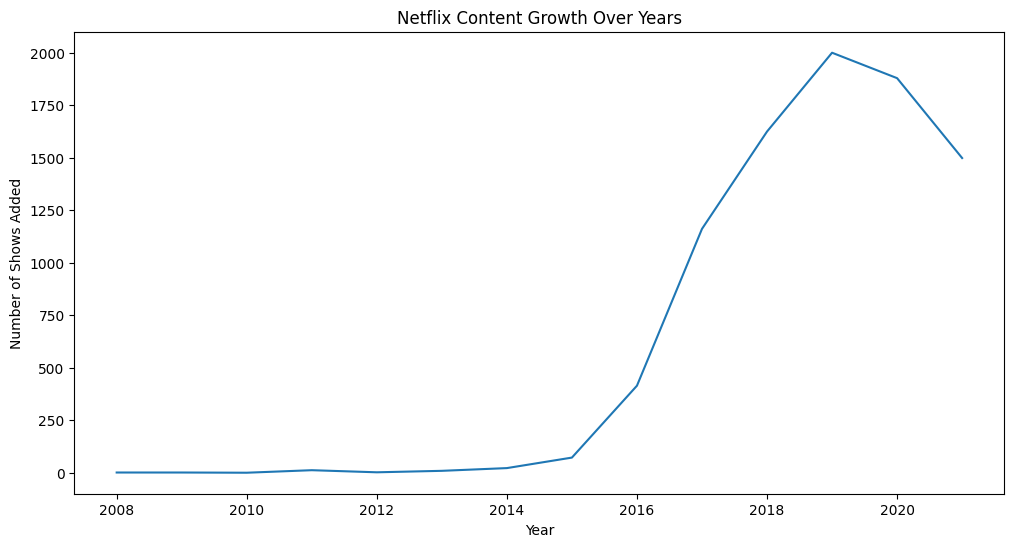

In [6]:
df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(12,6))

df['year_added'].value_counts().sort_index().plot(kind='line')

plt.title("Netflix Content Growth Over Years")

plt.xlabel("Year")
plt.ylabel("Number of Shows Added")

plt.show()

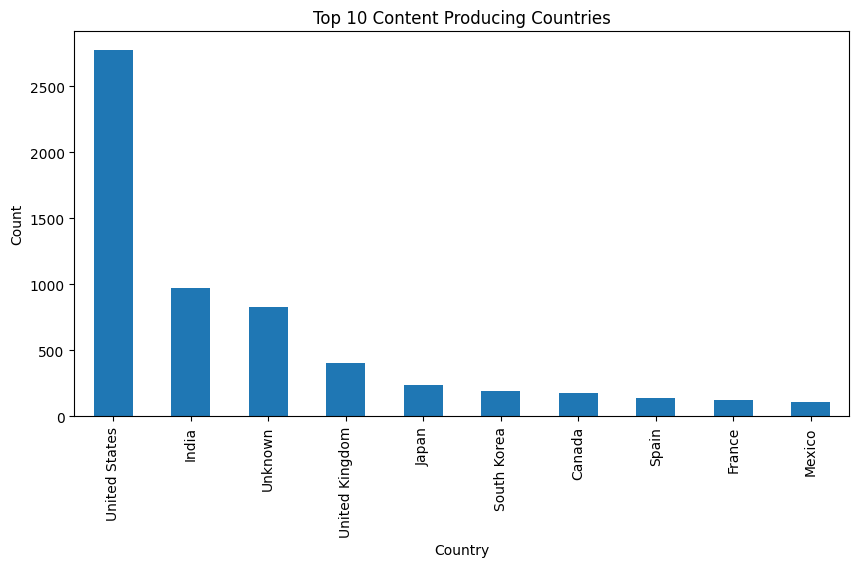

In [7]:
plt.figure(figsize=(10,5))

top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title("Top 10 Content Producing Countries")

plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

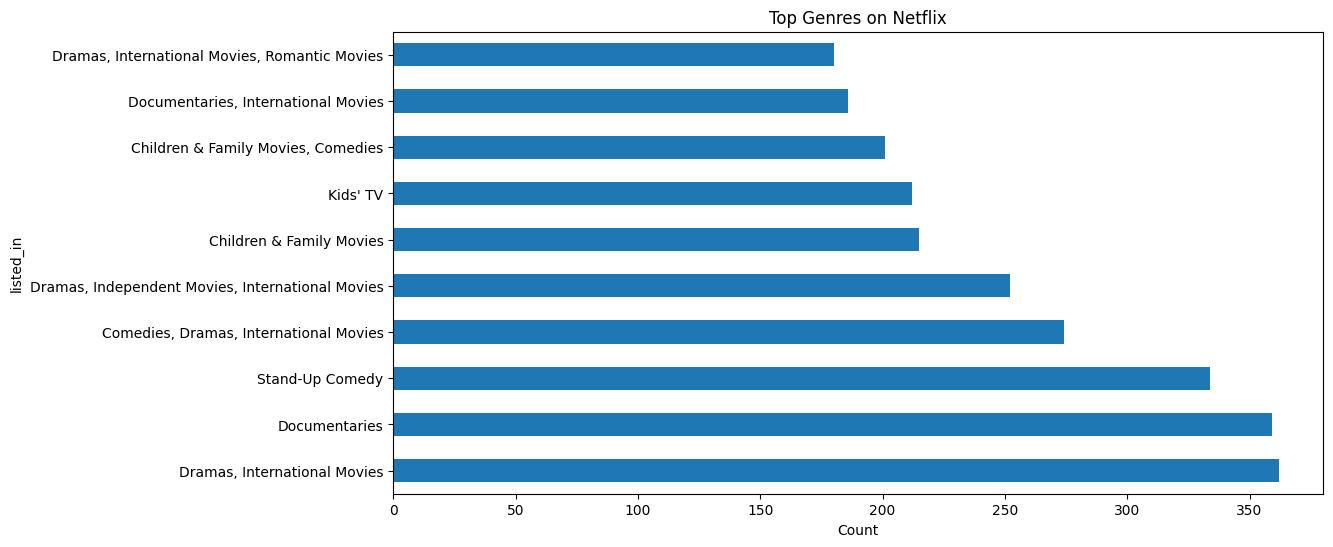

In [8]:
plt.figure(figsize=(12,6))

top_genres = df['listed_in'].value_counts().head(10)

top_genres.plot(kind='barh')

plt.title("Top Genres on Netflix")

plt.xlabel("Count")

plt.show()

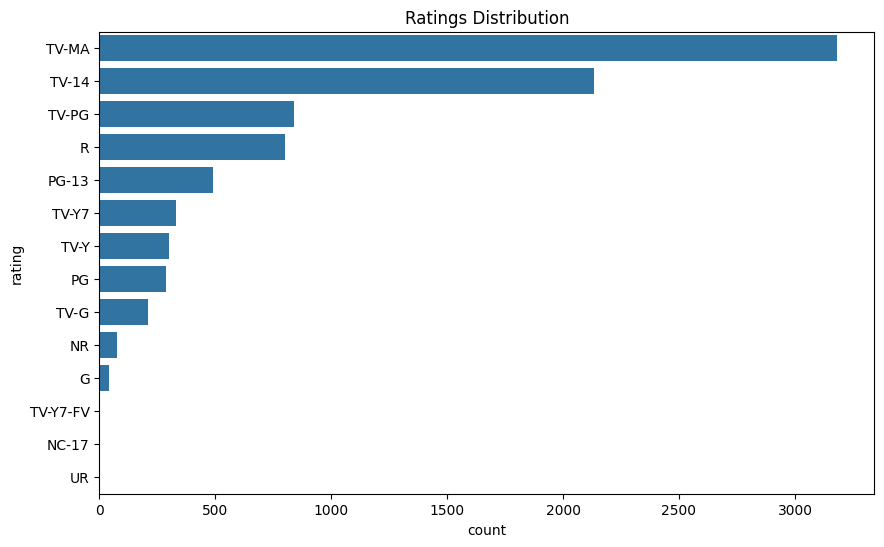

In [9]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Ratings Distribution")

plt.show()

# Business Insights

- Netflix contains significantly more Movies than TV Shows.
- The USA contributes the highest amount of content.
- TV-MA is the most common audience rating.
- Netflix content growth accelerated after 2015.
- International and Drama genres dominate the platform.
- Data analysis helps understand customer preferences and content trends.